Important Functions:

In [25]:
import numpy as np                   #importing numpy package for scientific computing
import matplotlib.pyplot as plt      #importing matplotlib package for plots
from scipy.signal import welch
import matplotlib
from matplotlib import animation
import pandas as pd


def load_data(filepath):
    # Load all data from the file, skipping the 7-line header
    raw = np.genfromtxt(filepath, delimiter=";", skip_header=7)

    time = raw[:, 0]
    EMF1 = raw[:, 1]
    EMF2 = raw[:, 2]
    EMF3 = raw[:, 3]
    EMF4 = raw[:, 4]
    EMF5 = raw[:, 5]

    # Remove the mean of the first 60 seconds (still water baseline)
    # This way any mean current in the signal is preserved
    still_water_mask = time < 60
    EMF1 -= np.mean(EMF1[still_water_mask])
    EMF2 -= np.mean(EMF2[still_water_mask])
    EMF3 -= np.mean(EMF3[still_water_mask])
    EMF4 -= np.mean(EMF4[still_water_mask])
    EMF5 -= np.mean(EMF5[still_water_mask])

    # Now trim the first and last 60 seconds
    mask = (time >= 200) & (time <= time[-1] - 200)
    time = time[mask]
    EMF1, EMF2, EMF3, EMF4, EMF5 = EMF1[mask], EMF2[mask], EMF3[mask], EMF4[mask], EMF5[mask]
    EMF1, EMF2, EMF3, EMF4, EMF5 = EMF1 * 0.08, EMF2 * 0.08, EMF3 * 0.08, EMF4 * 0.08, EMF5 * 0.08
    return time, EMF1, EMF2, EMF3, EMF4, EMF5

def plot_time_series(time, EMF1, EMF2, EMF3, EMF4, EMF5):
    fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

    for i, (ax, EMF) in enumerate(zip(axes, [EMF1, EMF2, EMF3, EMF4, EMF5]), start=1):
        ax.plot(time, EMF, label=f'EMF{i}')
        ax.set_ylabel('Velocity (m/s)')
        ax.set_title(f'EMF{i}')
        ax.legend(loc='upper right')
        ax.grid()

    axes[-1].set_xlabel('Time (s)')
    plt.suptitle('Time Series at all EMF locations')
    plt.tight_layout()
    plt.show()

def plot_time_series_limited(time, EMF1, EMF2, EMF3, EMF4, EMF5):
    fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

    for i, (ax, EMF) in enumerate(zip(axes, [EMF1, EMF2, EMF3, EMF4, EMF5]), start=1):
        ax.plot(time, EMF, label=f'EMF{i}')
        ax.set_ylabel('Velocity (m/s)')
        ax.set_title(f'EMF{i}')
        ax.legend(loc='upper right')
        ax.grid()

    axes[-1].set_xlabel('Time (s)')
    axes[-1].set_xlim(400, 420)
    plt.suptitle('Time Series at all EMF locations')
    plt.tight_layout()
    plt.show()

def read_grid(name_table, nx):
    grp = np.loadtxt(name_table, skiprows=0)
    ns, no = grp.shape
    nt = round(ns/nx)
    A = np.reshape(grp, (nx, nt, no), order="F")
    x    =  A[:, 0, 1]
    zbed = -A[:, 0, 3]

    # Shift zbed so the flat bottom starts at 0
    zbed = zbed - zbed.min()

    # Water depth at each EMF location (1-6)


    return x, zbed

def plot_flume(x, zbed, setup):
    emf_positions = [3.95, 8.06, 14.03, 15.97, 19.98]

    water_levels  = {1: 0.510, 2: 0.509, 3: 0.508, 4: 0.507, 5: 0.506, 6: 0.505}
    water_level = water_levels[setup]

    plt.figure(figsize=(14, 4))
    plt.plot(x, zbed, color='black', label='Bed profile')
    plt.fill_between(x, zbed, 0, color='sandybrown', alpha=0.5)
    plt.axhline(y=water_level, color='blue', alpha=0.3, label=f'Water surface (h={water_level}m)')



    for i, pos in enumerate(emf_positions):
        plt.axvline(x=pos, linestyle='--', label=f'EMF{i+1} ({pos}m)')

    plt.xlabel('x (m)')
    plt.ylabel('Elevation (m)')
    plt.title('Flume bed profile with EMF sensor locations')
    plt.legend(loc='upper left')
    plt.grid()
    plt.show()

def plot_sediment_transport(time, EMF1, EMF2, EMF3, EMF4, EMF5, Fs):
    emf_positions = [3.95, 8.06, 14.03, 15.97, 19.98]  # only 5 sensors
    emf_data      = [EMF1, EMF2, EMF3, EMF4, EMF5]  # only 5 sensors

    # --- Compute all terms at each EMF location ---
    u3            = []
    u3_ss         = []
    three_u2ss_u  = []
    three_u2ss_uig= []
    sed_total     = []

    for EMF in emf_data:
        u_mean      = np.mean(EMF)
        u_demeaned  = EMF - u_mean

        # Sea-swell band (0.05 - 1.0 Hz)
        u_ss        = frequency_filter(u_demeaned, Fs, f_low=0.05, f_high=1.0)

        # Infragravity band (0.005 - 0.05 Hz)
        u_ig        = frequency_filter(u_demeaned, Fs, f_low=0.005, f_high=0.05)

        u3.append(u_mean ** 3)
        u3_ss.append(np.mean(u_ss ** 3))
        three_u2ss_u.append(np.mean(3 * (u_ss ** 2) * u_mean))
        three_u2ss_uig.append(np.mean(3 * (u_ss ** 2) * u_ig))
        sed_total.append(u_mean**3 + np.mean(u_ss**3) + np.mean(3*(u_ss**2)*u_mean) + np.mean(3*(u_ss**2)*u_ig))

    # --- Plot as points at the 5 EMF locations ---
    plt.figure(figsize=(12, 4))
    plt.plot(emf_positions, u3,             label='Mean current',             color='red',    marker='o', markersize=4)
    plt.plot(emf_positions, u3_ss,          label='Skewness',                 color='blue',   marker='o', markersize=4)
    plt.plot(emf_positions, three_u2ss_u,   label='Stirring term',            color='green',  marker='o', markersize=4)
    plt.plot(emf_positions, three_u2ss_uig, label='Infragravity term',        color='purple', marker='o', markersize=4)
    plt.plot(emf_positions, sed_total,      label='Total sediment transport', color='black',  marker='o', markersize=4)

    plt.xlabel('x (m)')
    plt.ylabel('Sediment transport proxy (m³/s³)')
    plt.legend()
    plt.grid()
    plt.show()

def frequency_filter(data, Fs, f_low, f_high):
    ''' frequency_filter is a simple spectral filter in which the unwanted frequencies (below f_low and above f_high) 
        are set to zero before coming back to the time-domain
            input: data timeseries you want to filter
                   F_s the sampling frequency of this timeseries (Hz)
                   f_low and f_high are the limits of the band pass filter (Hz)
            output: data_filtered band pass filtered timeseries (same unit as the input timeseries)
    '''
    
    N = len(data)

    fft_data = np.fft.fft(data)  # fourier transform of the signal

    freq_vector = np.fft.fftfreq(N, d=1/Fs) # corresponding (2-sided) frequency axis (includes positive and negative values)
    
    idx = np.where((abs(freq_vector) > f_high) | (abs(freq_vector) <= f_low)) # we select the indices to filter out
    
    fft_data[idx]=0.  # we set the the fourier coefficients corresponding to abs(f)>f_high and abs(f)<f_low to zero

    data_filtered = np.fft.ifft(fft_data).real  # we come back to the time domain with an inverse Fourier transform
    
    return data_filtered

Grid Plot for Setup 1:

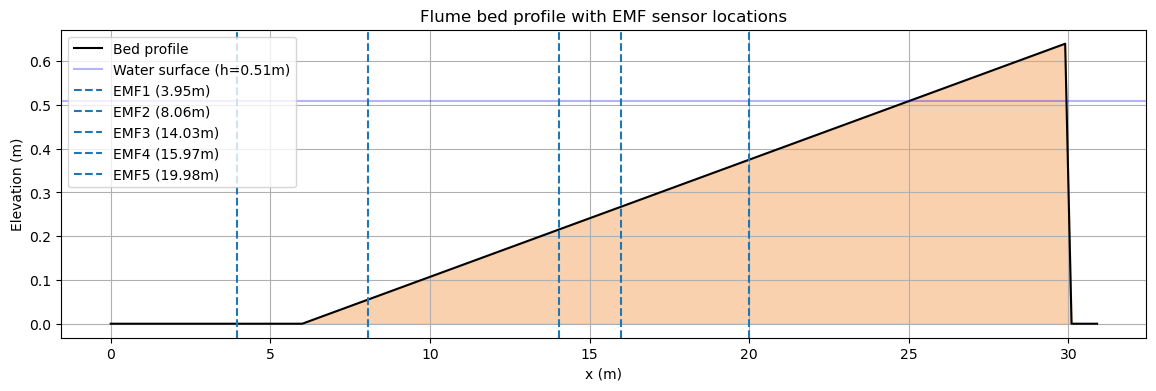

In [26]:
x, zbed = read_grid("grid_output.tbl", 310)
plot_flume(x, zbed, 1)

Plot Raw Velocity profiles at different sensor locations:

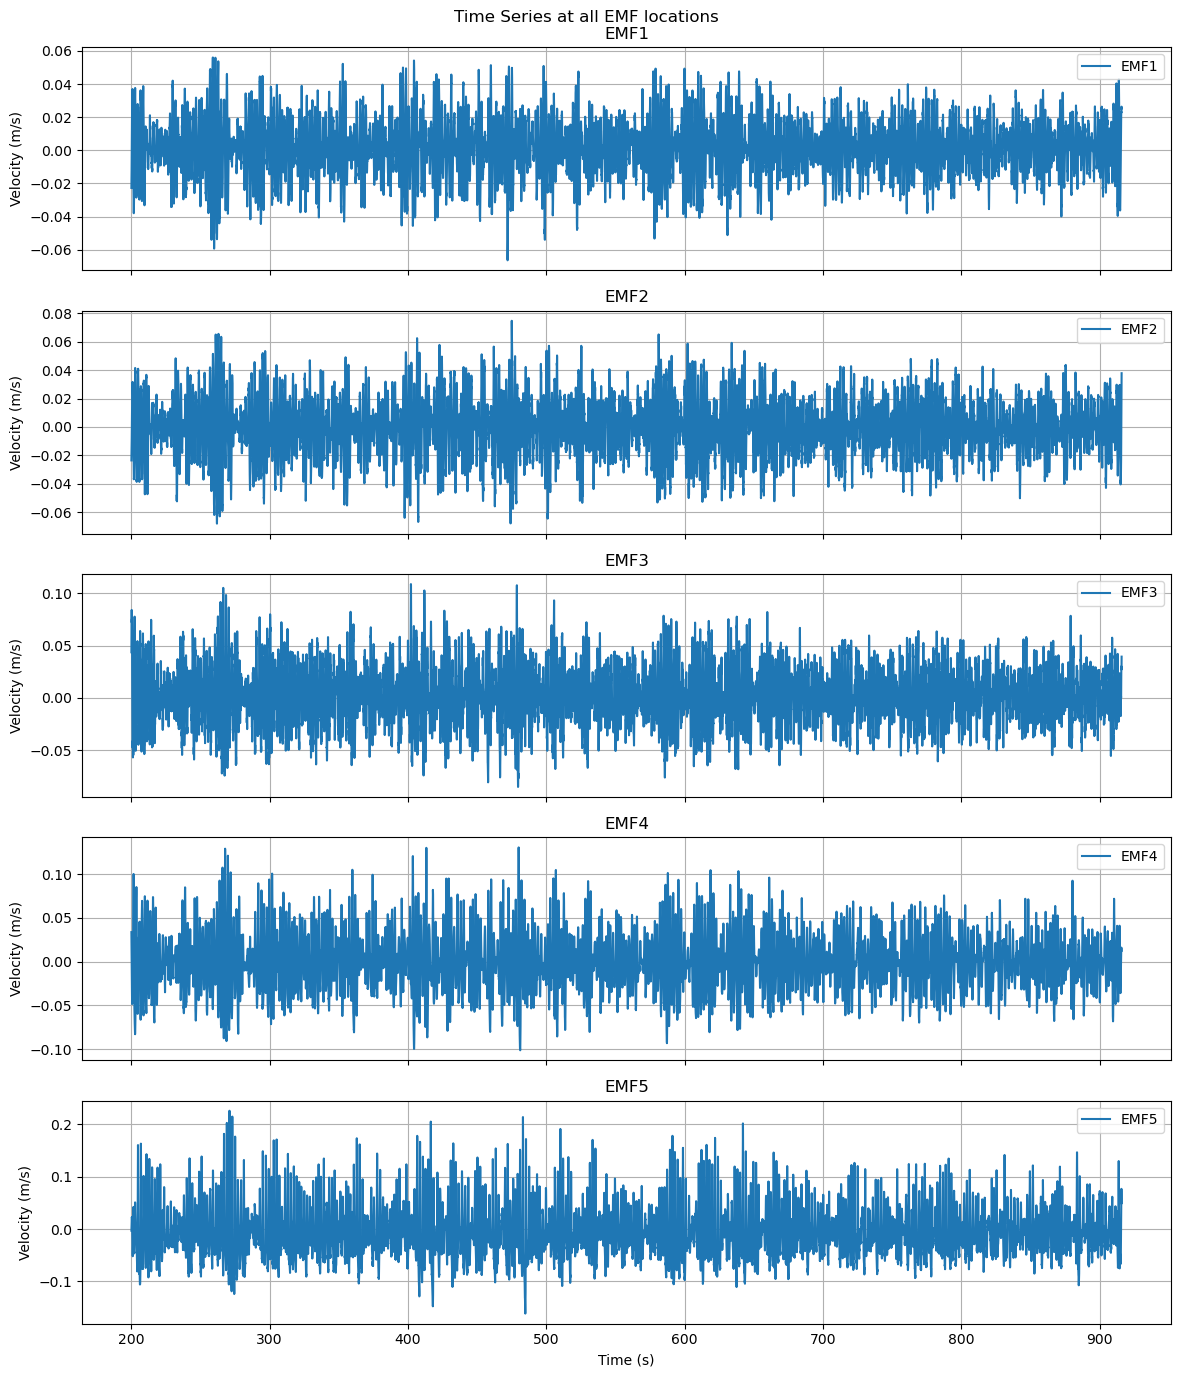

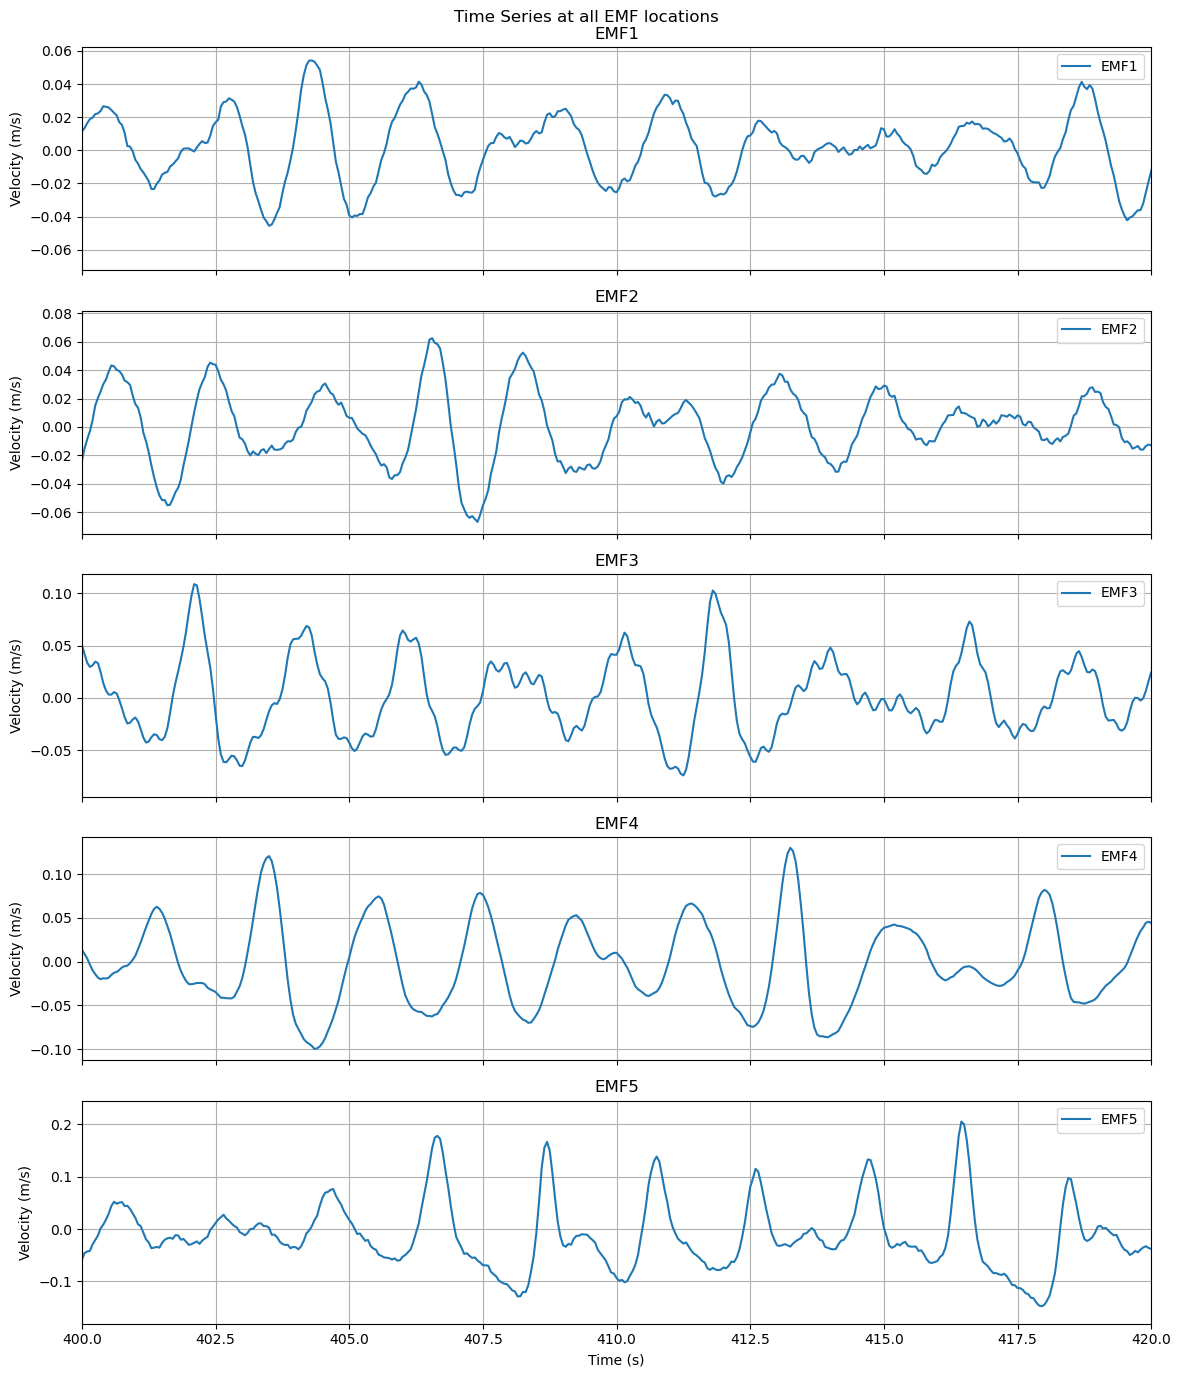

In [27]:
time1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03 = load_data('Set1/EMF_test1.ASC')
plot_time_series(time1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03)
plot_time_series_limited(time1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03)

Plot Velocity Moments 3cm:

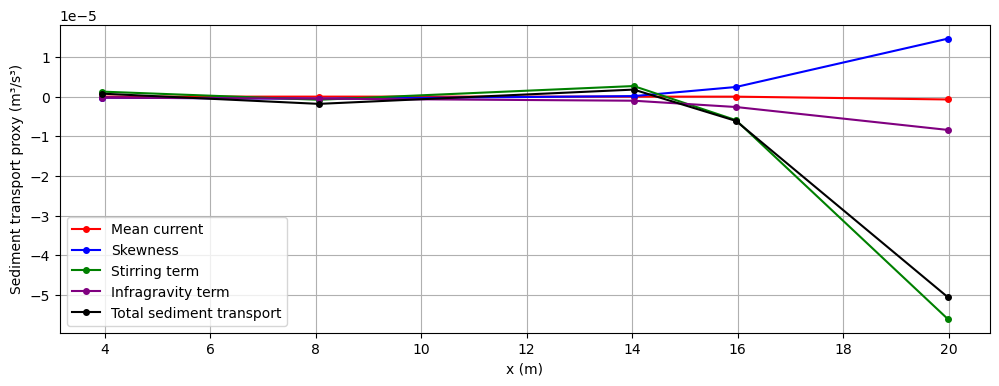

In [28]:
plot_sediment_transport(time1, EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03, Fs=20)

Plot Velocity Moments 6cm:

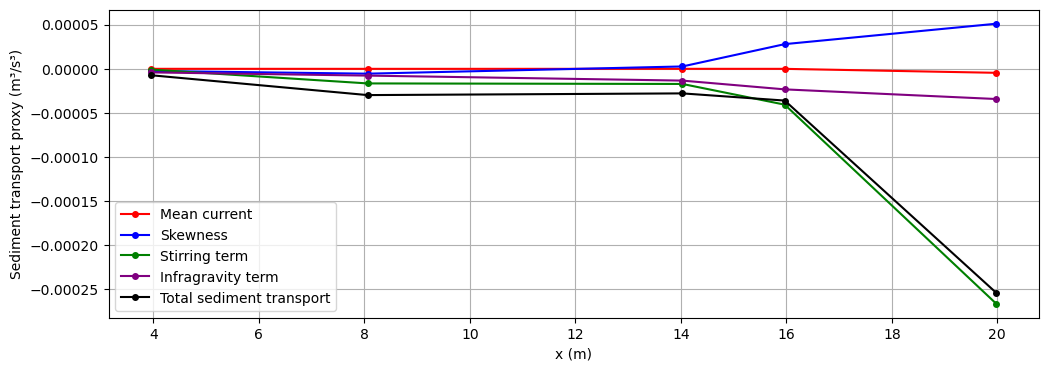

In [29]:
time2, EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06 = load_data('Set2/EMF_test2.ASC')
plot_sediment_transport(time2, EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06, Fs=20)

Plot Velocity Moments 9cm:

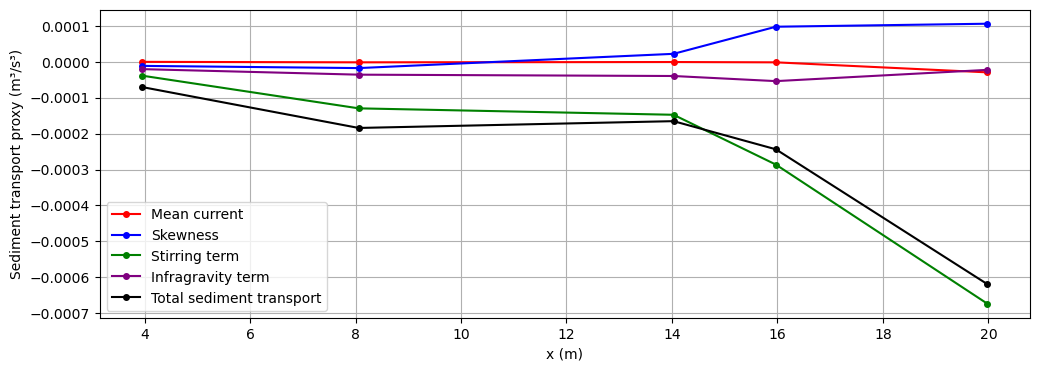

In [30]:
time3, EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09 = load_data('Set3/EMF_test3.ASC')
plot_sediment_transport(time3, EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09, Fs=20)

Plot Velocity Moments 12cm:

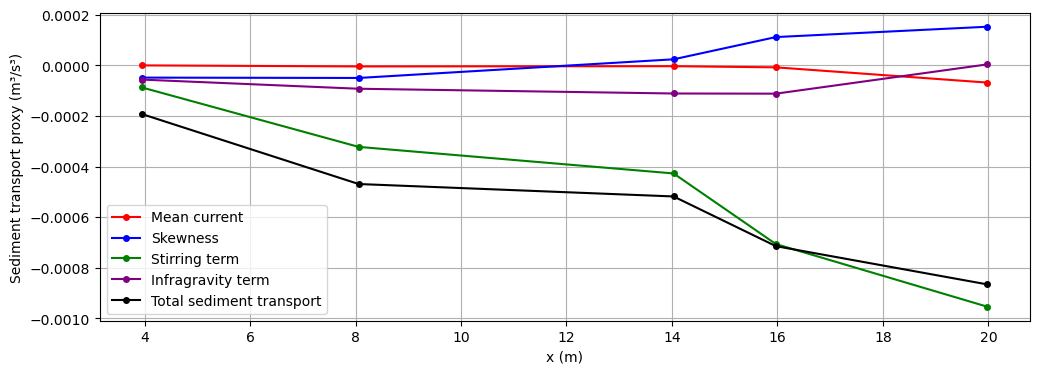

In [31]:
time4, EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12 = load_data('Set4/EMF_test4.ASC')
plot_sediment_transport(time4, EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12, Fs=20)

Plot Velocity Moments 15cm:

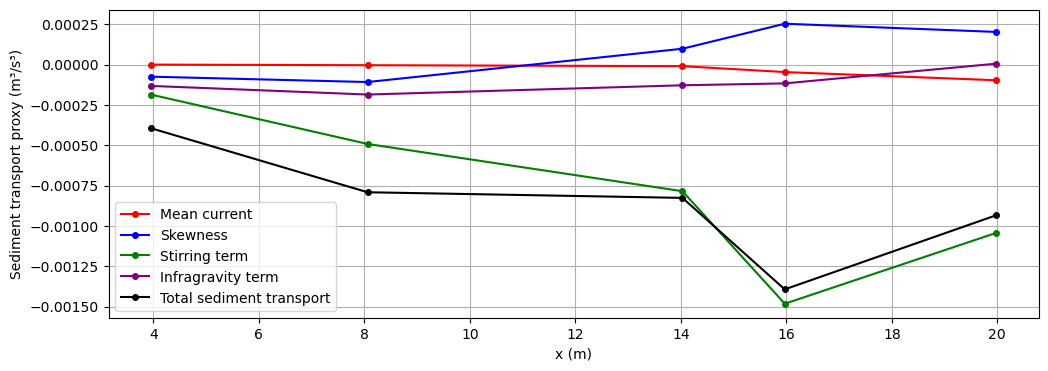

In [32]:
time5, EMF1_15, EMF2_15, EMF3_15, EMF4_15, EMF5_15 = load_data('Set5/EMF_test5.ASC')
plot_sediment_transport(time5, EMF1_15, EMF2_15, EMF3_15, EMF4_15, EMF5_15, Fs=20)

Plot Velocity Moments 18cm:

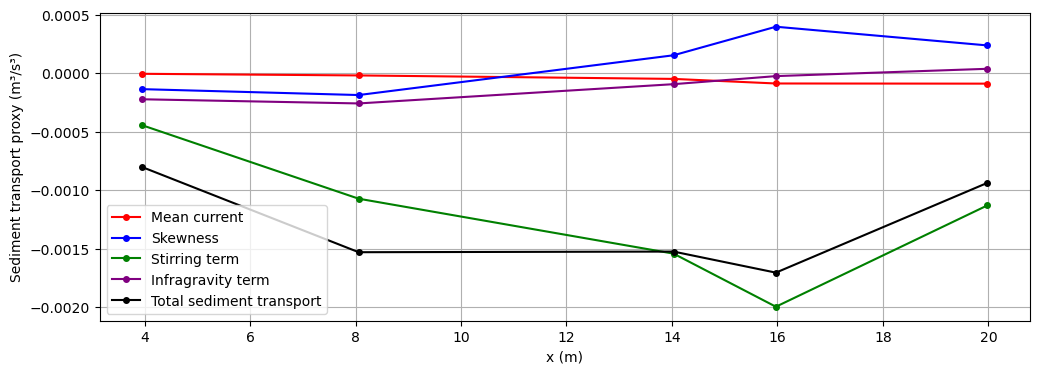

In [33]:
time6, EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18 = load_data('Set6/EMF_test6.ASC')
plot_sediment_transport(time6, EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18, Fs=20)

Swash Simulations Functions:

In [34]:
def read_point_output(name_table):
    '''reads the wave gauge output type 
            input: name_table is the name of the output table (e.g. name_table="gauge1.tbl" in the original SWASH input file)
            outputs:
                t: vector containing the time in s
                eta: vector containing the surface elevation in m
                ux: vector containing the depth averaged horizontal velocity in m/s
    '''
    
    gauge = np.loadtxt(name_table,skiprows=7)

    t   = gauge[:,0] #time vector (s)
    ux  = gauge[:,2] #depth-averaged velocity in the x-direction (m/s)
    #uy = gauge[:,3] #depth-averaged velocity in the y-direction (0 at all time because we are looking at a 1D case)
    
    return t, ux #, uy

def plot_sediment_transport(time, EMF1, EMF2, EMF3, EMF4, EMF5, Fs, ax):
    emf_positions = [3.95, 8.06, 14.03, 15.97, 19.98]
    emf_data      = [EMF1, EMF2, EMF3, EMF4, EMF5]

    u3, u3_ss, three_u2ss_u, three_u2ss_uig, sed_total = [], [], [], [], []

    for EMF in emf_data:
        u_mean  = np.mean(EMF)
        u_dem   = EMF - u_mean
        u_ss    = frequency_filter(u_dem, Fs, f_low=0.25,  f_high=1.0)
        u_ig    = frequency_filter(u_dem, Fs, f_low=0.005, f_high=0.25)

        u3.append(u_mean ** 3)
        u3_ss.append(np.mean(u_ss ** 3))
        three_u2ss_u.append(np.mean(3 * (u_ss ** 2) * u_mean))
        three_u2ss_uig.append(np.mean(3 * (u_ss ** 2) * u_ig))
        sed_total.append(u_mean**3 + np.mean(u_ss**3) + np.mean(3*(u_ss**2)*u_mean) + np.mean(3*(u_ss**2)*u_ig))

    ax.plot(emf_positions, u3,             label='Mean current',             color='red',    marker='o', markersize=4)
    ax.plot(emf_positions, u3_ss,          label='Skewness',                 color='blue',   marker='o', markersize=4)
    ax.plot(emf_positions, three_u2ss_u,   label='Stirring term',            color='green',  marker='o', markersize=4)
    ax.plot(emf_positions, three_u2ss_uig, label='Infragravity term',        color='purple', marker='o', markersize=4)
    ax.plot(emf_positions, sed_total,      label='Total sediment transport', color='black',  marker='o', markersize=4)
    ax.grid()

Get the Data from Simulations:

In [35]:
time1_swash, ux1_1 = read_point_output('Set1Swash/gauge1.tbl')
time1_swash, ux1_2 = read_point_output('Set1Swash/gauge2.tbl')
time1_swash, ux1_3 = read_point_output('Set1Swash/gauge3.tbl')
time1_swash, ux1_4 = read_point_output('Set1Swash/gauge4.tbl')
time1_swash, ux1_5 = read_point_output('Set1Swash/gauge5.tbl')

time2_swash, ux2_1 = read_point_output('Set2Swash/gauge1.tbl')
time2_swash, ux2_2 = read_point_output('Set2Swash/gauge2.tbl')
time2_swash, ux2_3 = read_point_output('Set2Swash/gauge3.tbl')
time2_swash, ux2_4 = read_point_output('Set2Swash/gauge4.tbl')
time2_swash, ux2_5 = read_point_output('Set2Swash/gauge5.tbl')

time3_swash, ux3_1 = read_point_output('Set3Swash/gauge1.tbl')
time3_swash, ux3_2 = read_point_output('Set3Swash/gauge2.tbl')
time3_swash, ux3_3 = read_point_output('Set3Swash/gauge3.tbl')
time3_swash, ux3_4 = read_point_output('Set3Swash/gauge4.tbl')
time3_swash, ux3_5 = read_point_output('Set3Swash/gauge5.tbl')

time4_swash, ux4_1 = read_point_output('Set4Swash/gauge1.tbl')
time4_swash, ux4_2 = read_point_output('Set4Swash/gauge2.tbl')
time4_swash, ux4_3 = read_point_output('Set4Swash/gauge3.tbl')
time4_swash, ux4_4 = read_point_output('Set4Swash/gauge4.tbl')
time4_swash, ux4_5 = read_point_output('Set4Swash/gauge5.tbl')

time5_swash, ux5_1 = read_point_output('Set5Swash/gauge1.tbl')
time5_swash, ux5_2 = read_point_output('Set5Swash/gauge2.tbl')
time5_swash, ux5_3 = read_point_output('Set5Swash/gauge3.tbl')
time5_swash, ux5_4 = read_point_output('Set5Swash/gauge4.tbl')
time5_swash, ux5_5 = read_point_output('Set5Swash/gauge5.tbl')

time6_swash, ux6_1 = read_point_output('Set6Swash/gauge1.tbl')
time6_swash, ux6_2 = read_point_output('Set6Swash/gauge2.tbl')
time6_swash, ux6_3 = read_point_output('Set6Swash/gauge3.tbl')
time6_swash, ux6_4 = read_point_output('Set6Swash/gauge4.tbl')
time6_swash, ux6_5 = read_point_output('Set6Swash/gauge5.tbl')


Plot Simulation against Experiment 3cm:

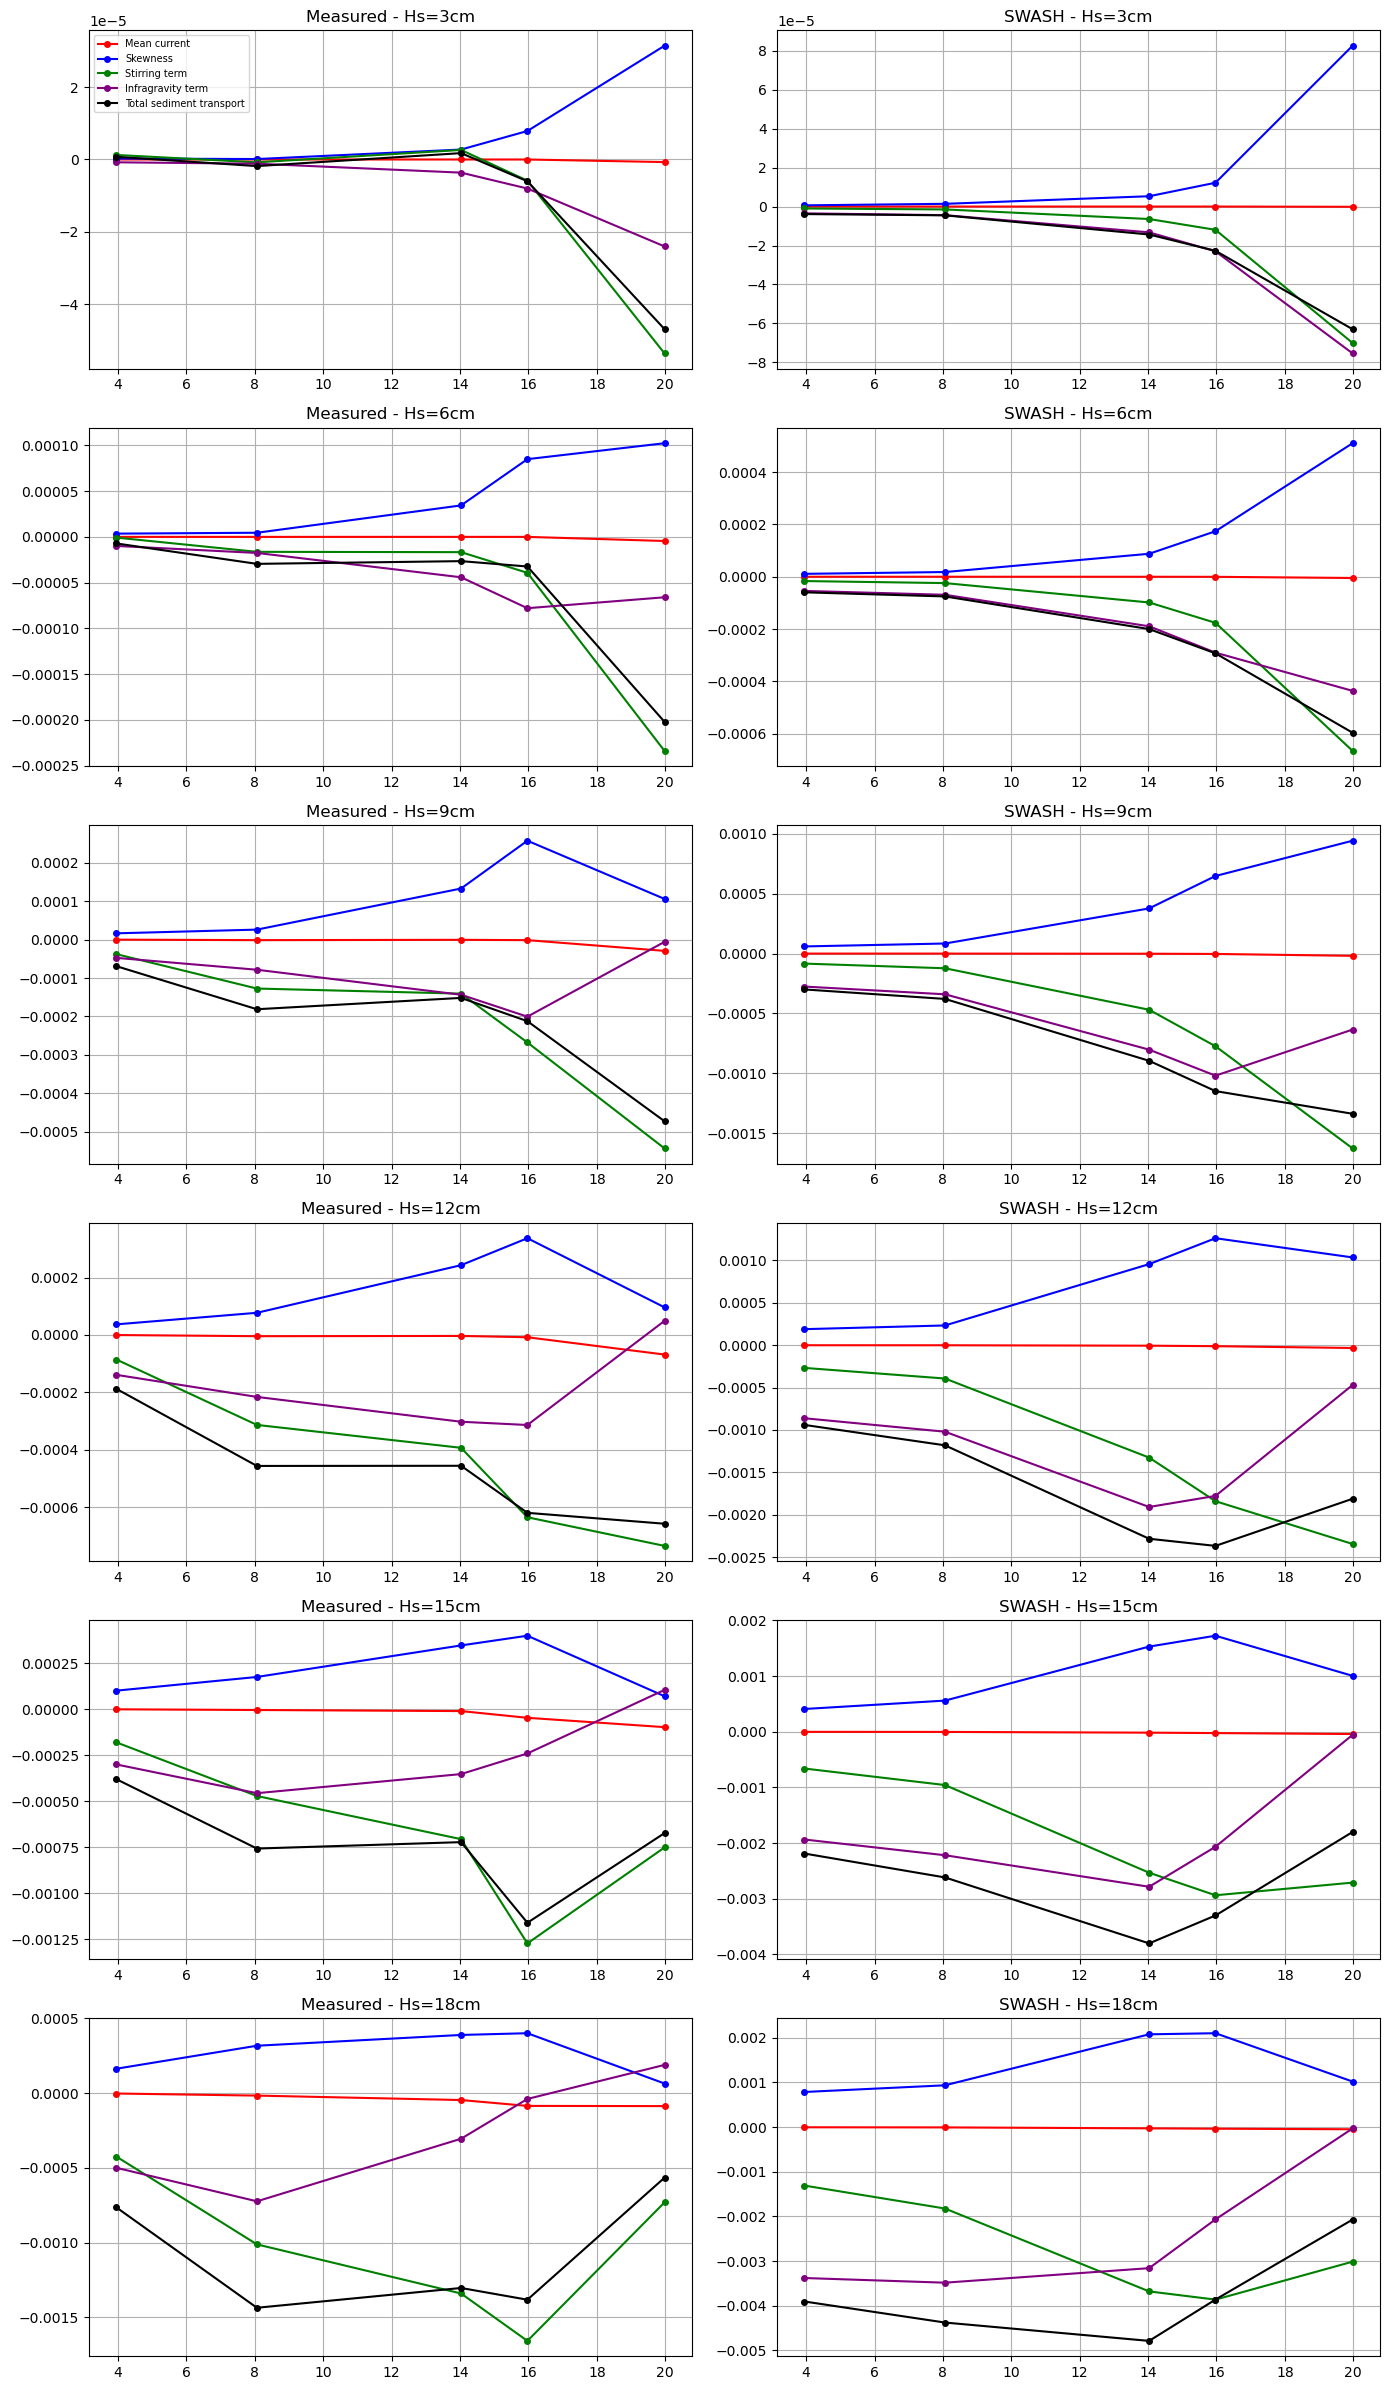

In [36]:
fig, axes = plt.subplots(6, 2, figsize=(14, 24))

plot_sediment_transport(time1,       EMF1_03, EMF2_03, EMF3_03, EMF4_03, EMF5_03, Fs=20, ax=axes[0,0])
plot_sediment_transport(time1_swash, ux1_1,   ux1_2,   ux1_3,   ux1_4,   ux1_5,   Fs=20, ax=axes[0,1])
plot_sediment_transport(time2,       EMF1_06, EMF2_06, EMF3_06, EMF4_06, EMF5_06, Fs=20, ax=axes[1,0])
plot_sediment_transport(time2_swash, ux2_1,   ux2_2,   ux2_3,   ux2_4,   ux2_5,   Fs=20, ax=axes[1,1])
plot_sediment_transport(time3,       EMF1_09, EMF2_09, EMF3_09, EMF4_09, EMF5_09, Fs=20, ax=axes[2,0])
plot_sediment_transport(time3_swash, ux3_1,   ux3_2,   ux3_3,   ux3_4,   ux3_5,   Fs=20, ax=axes[2,1])
plot_sediment_transport(time4,       EMF1_12, EMF2_12, EMF3_12, EMF4_12, EMF5_12, Fs=20, ax=axes[3,0])
plot_sediment_transport(time4_swash, ux4_1,   ux4_2,   ux4_3,   ux4_4,   ux4_5,   Fs=20, ax=axes[3,1])
plot_sediment_transport(time5,       EMF1_15, EMF2_15, EMF3_15, EMF4_15, EMF5_15, Fs=20, ax=axes[4,0])
plot_sediment_transport(time5_swash, ux5_1,   ux5_2,   ux5_3,   ux5_4,   ux5_5,   Fs=20, ax=axes[4,1])
plot_sediment_transport(time6,       EMF1_18, EMF2_18, EMF3_18, EMF4_18, EMF5_18, Fs=20, ax=axes[5,0])
plot_sediment_transport(time6_swash, ux6_1,   ux6_2,   ux6_3,   ux6_4,   ux6_5,   Fs=20, ax=axes[5,1])

for i, hs in enumerate(['3cm', '6cm', '9cm', '12cm', '15cm', '18cm']):
    axes[i, 0].set_title(f'Measured - Hs={hs}')
    axes[i, 1].set_title(f'SWASH - Hs={hs}')

axes[0, 0].legend(fontsize=7)
plt.tight_layout()
plt.show()

Compute the Wave Spectrum

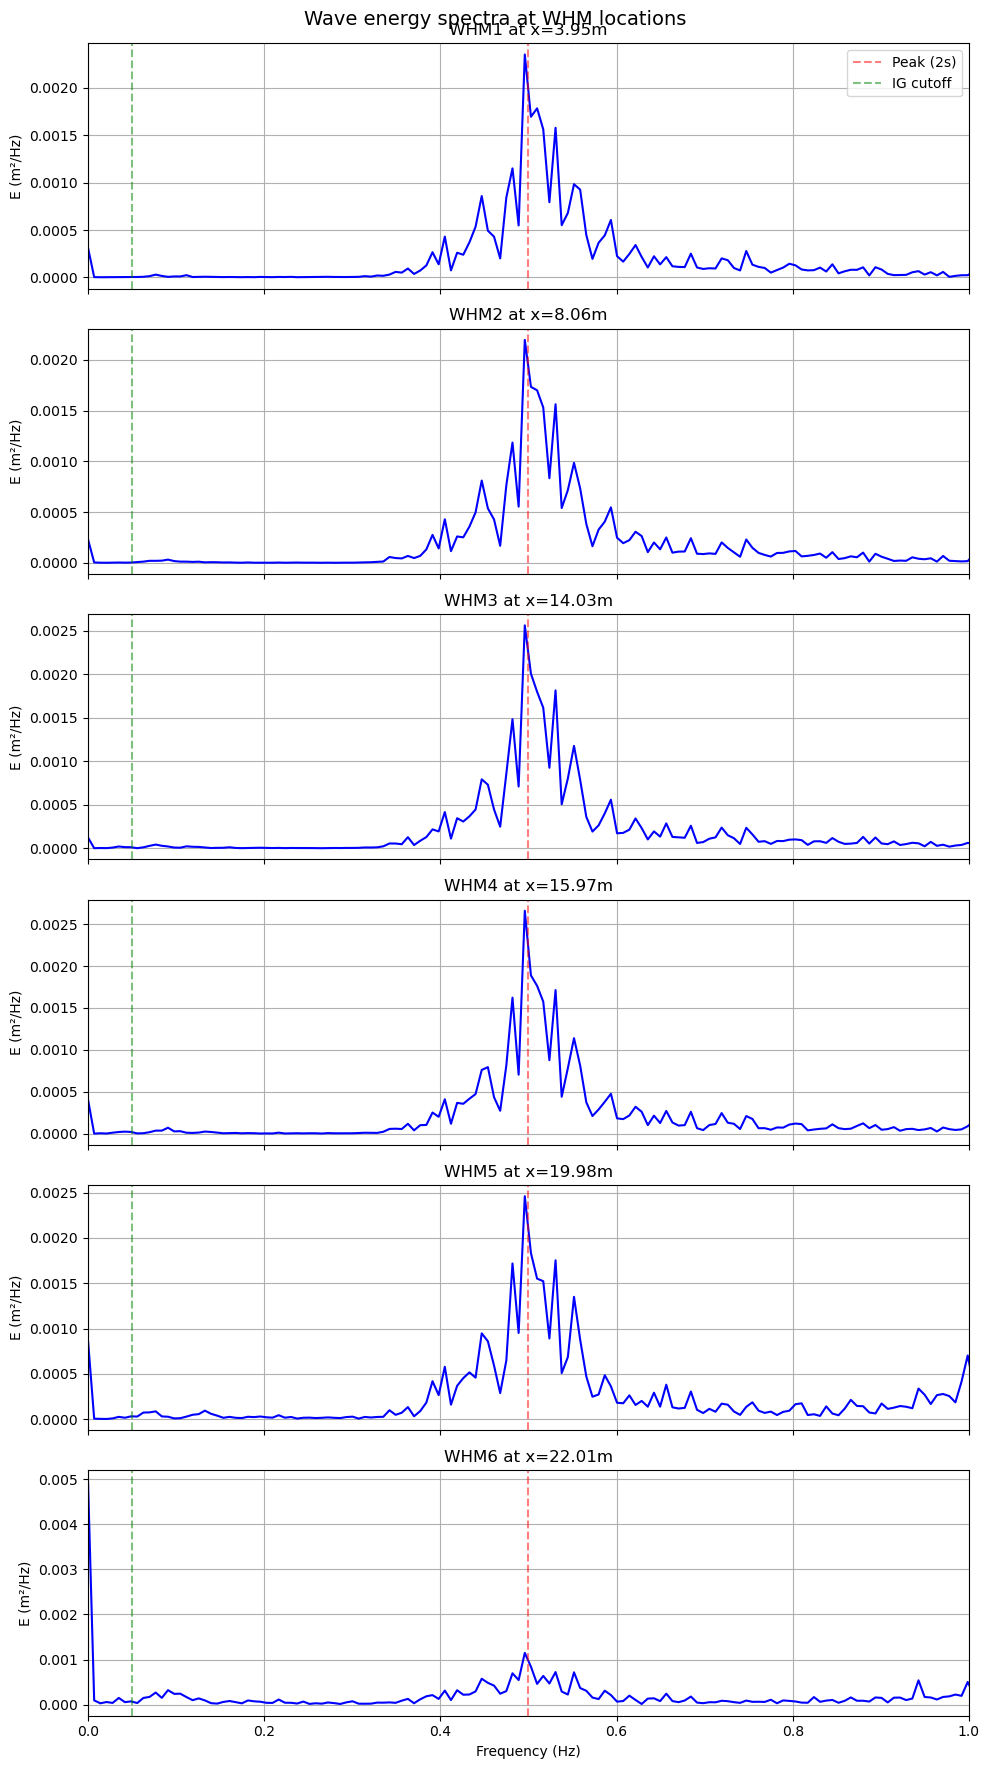

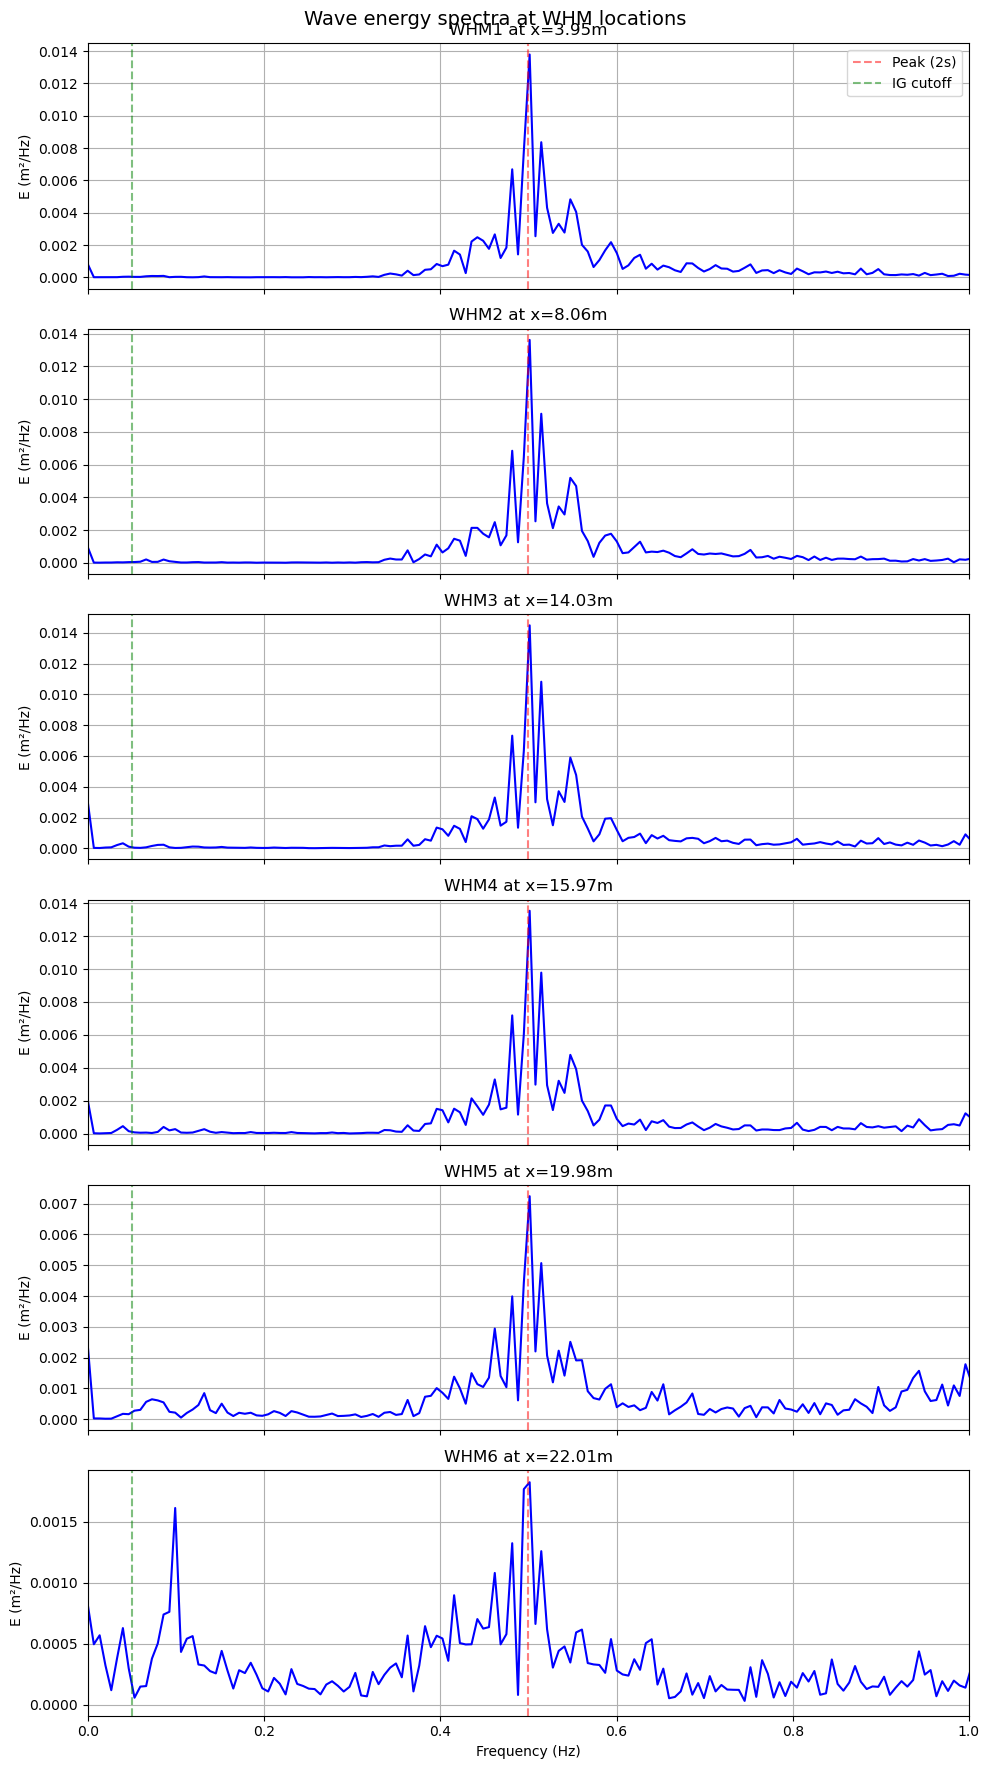

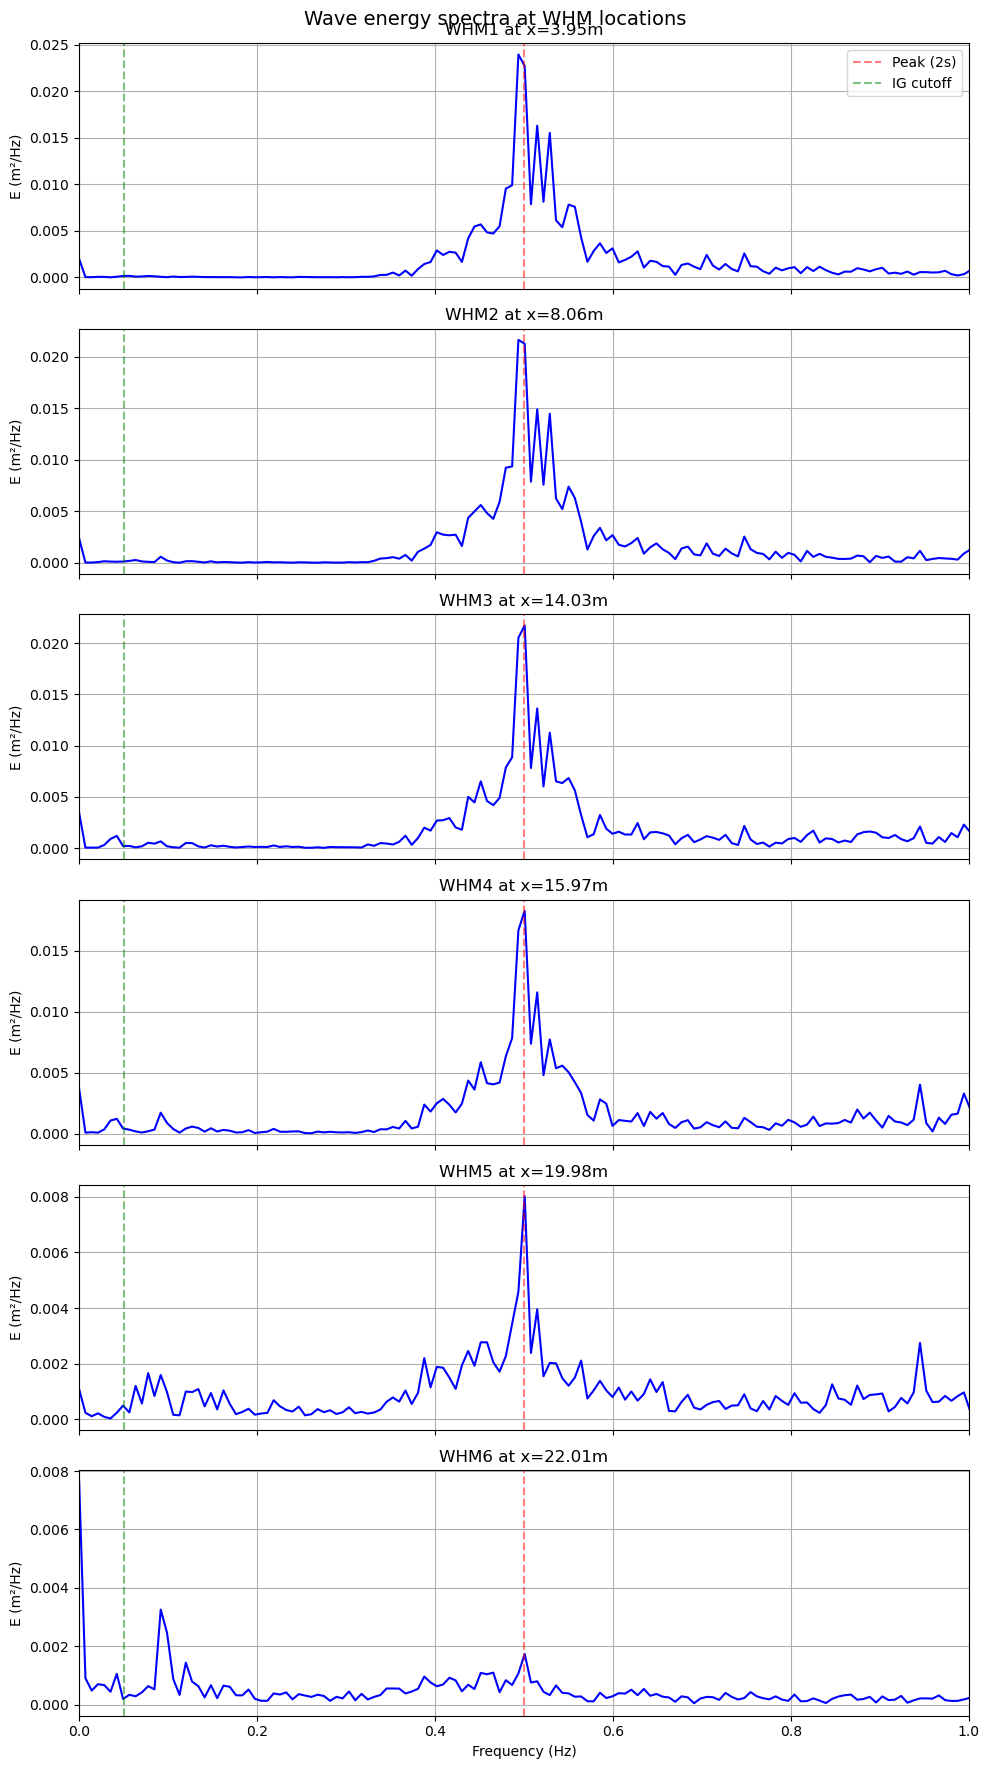

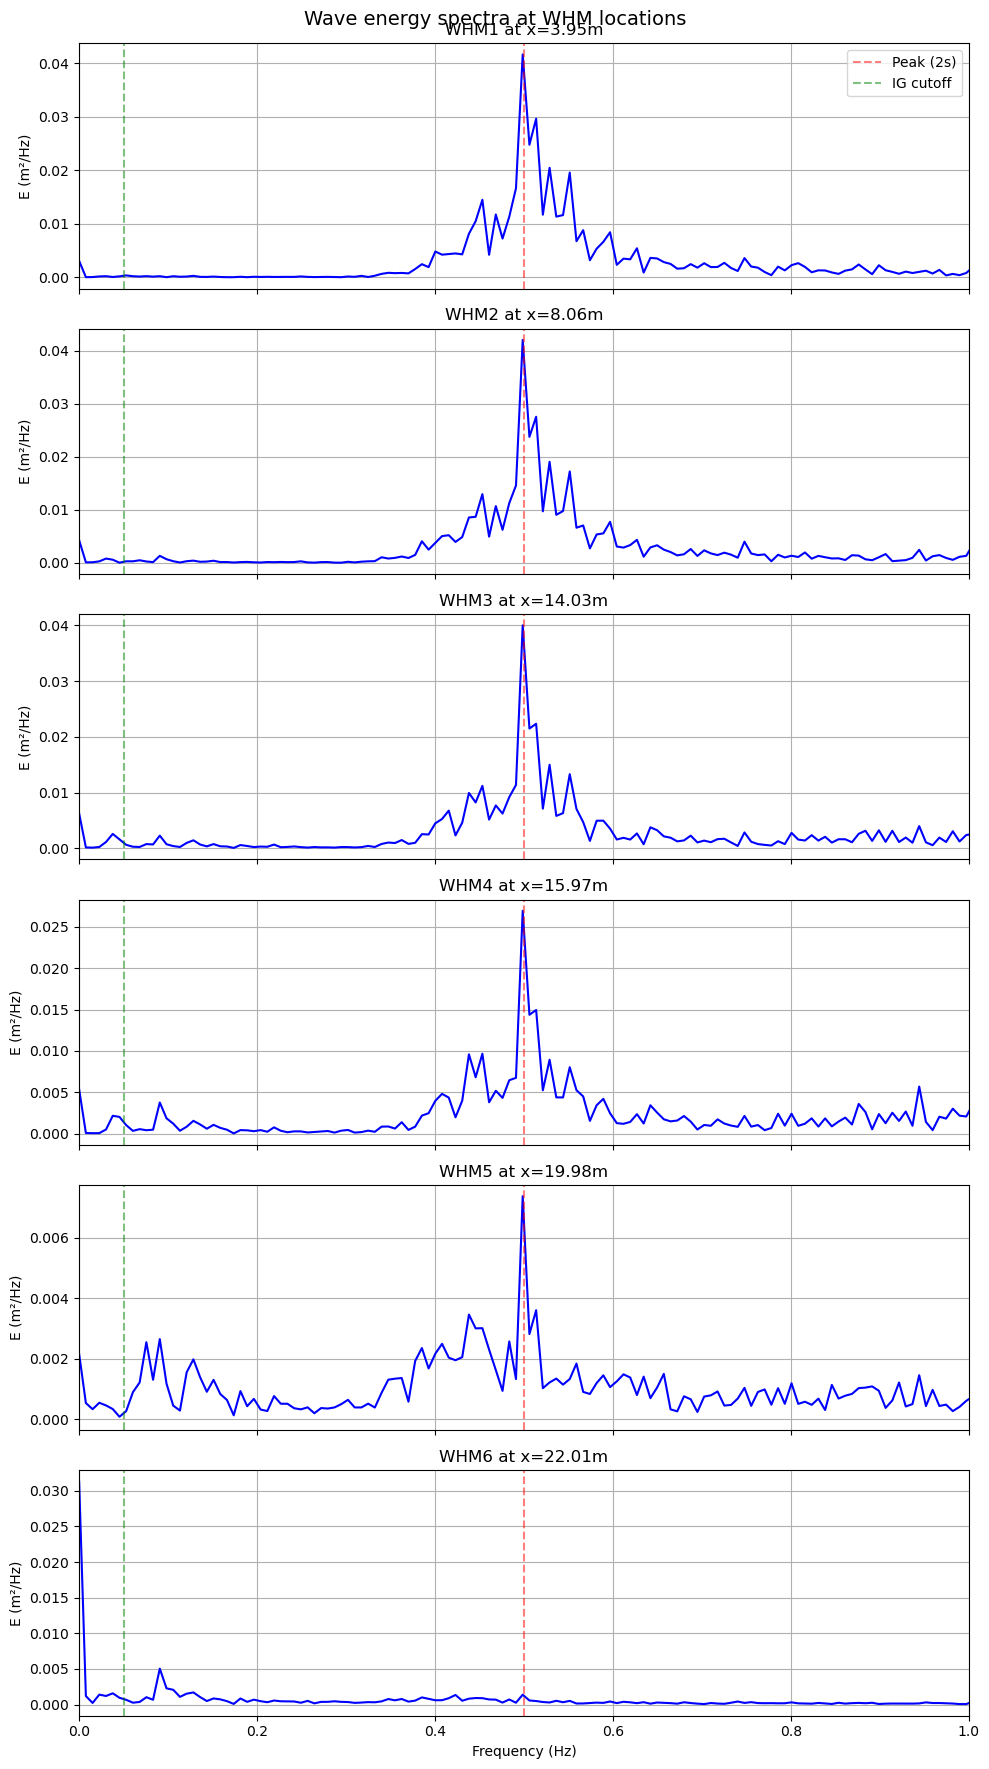

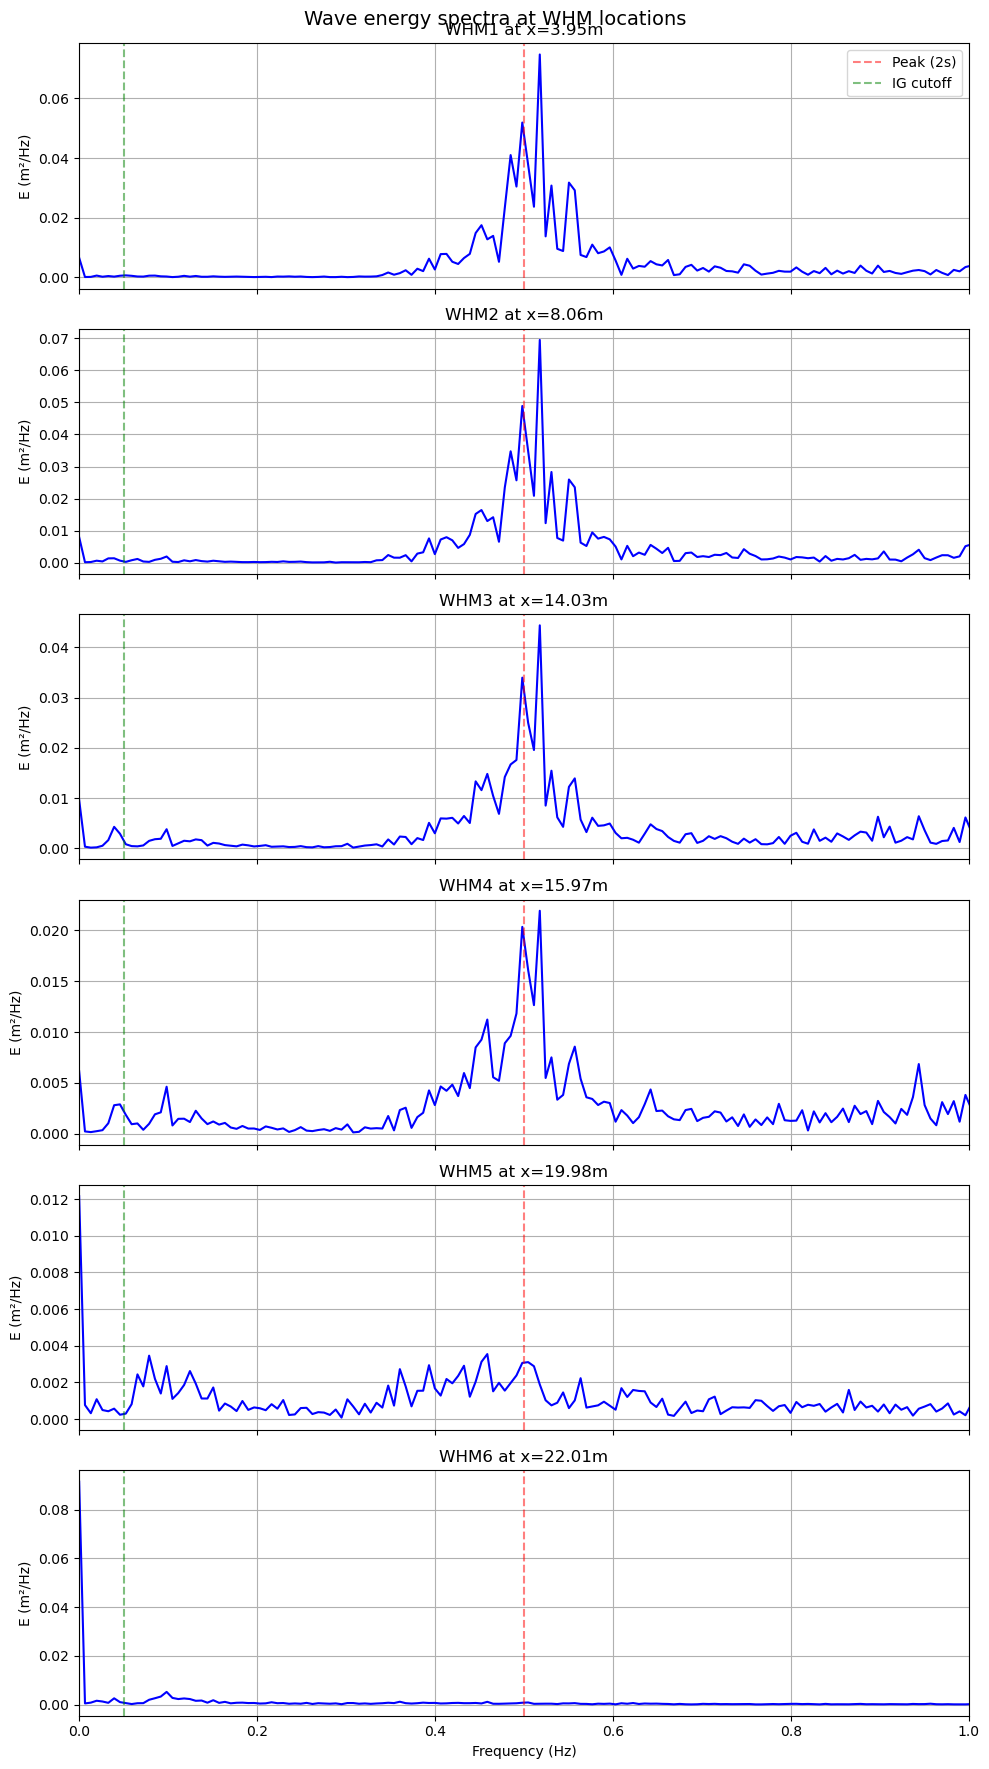

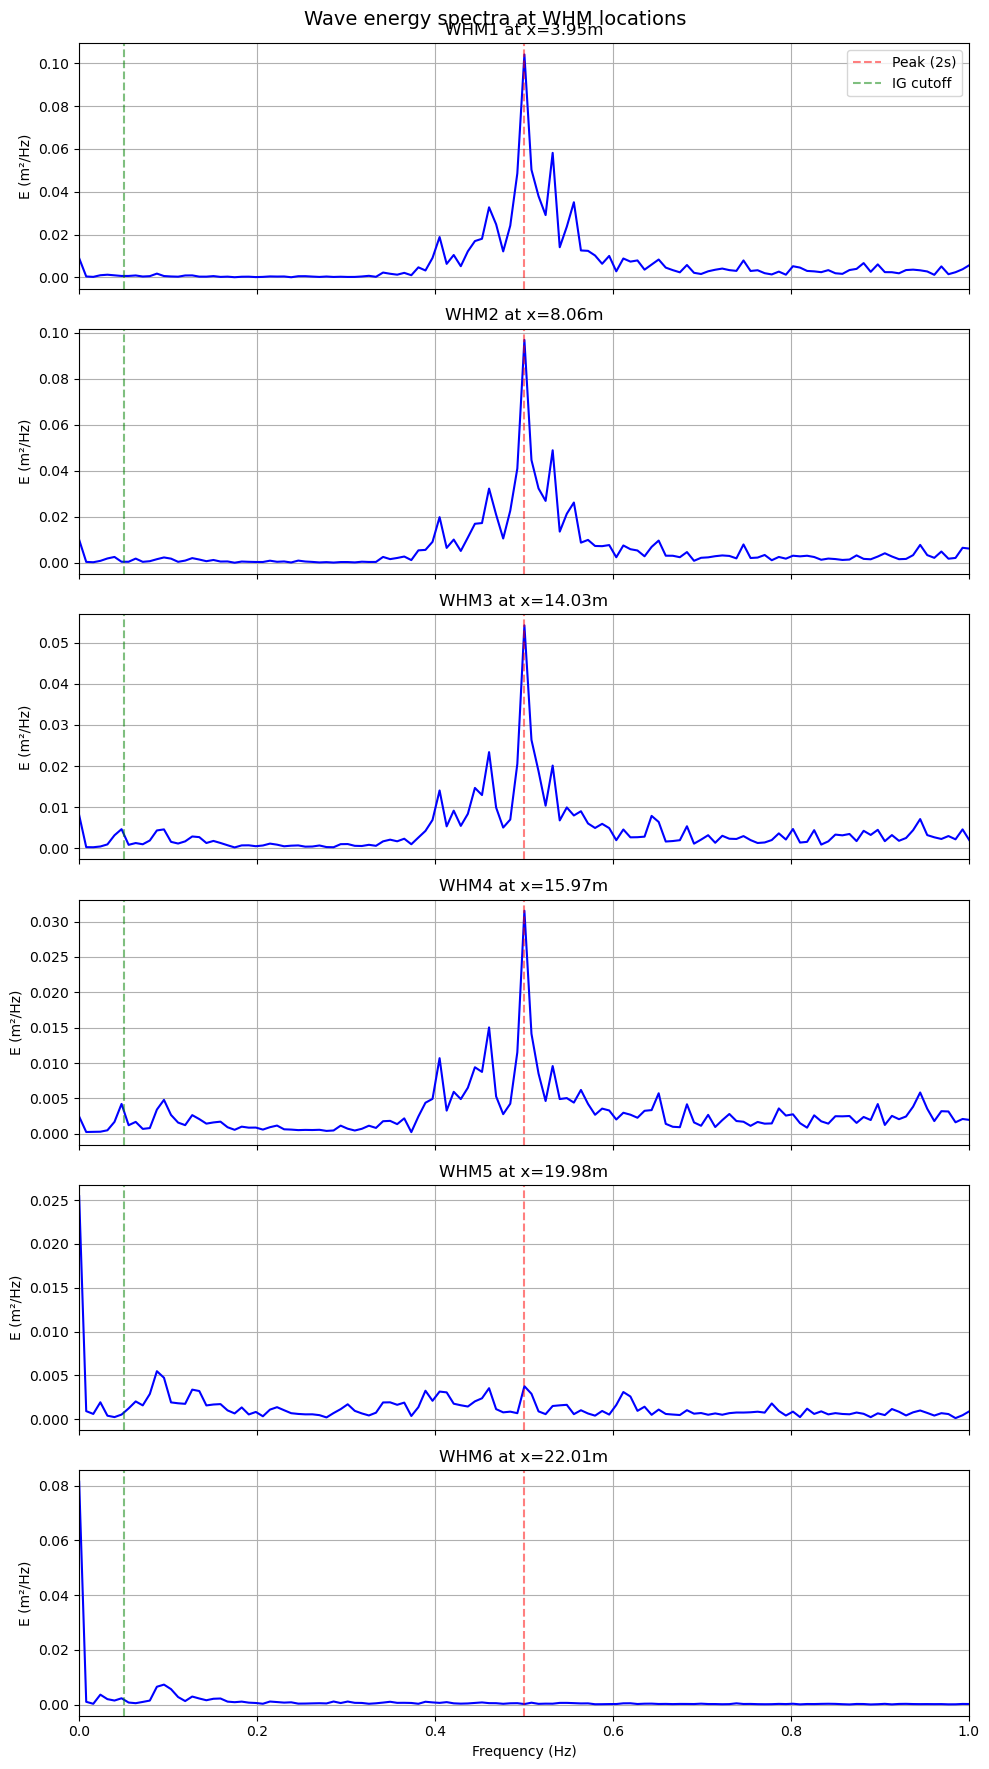

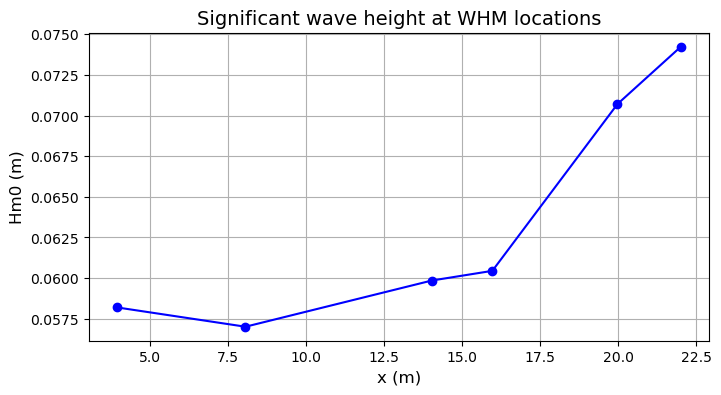

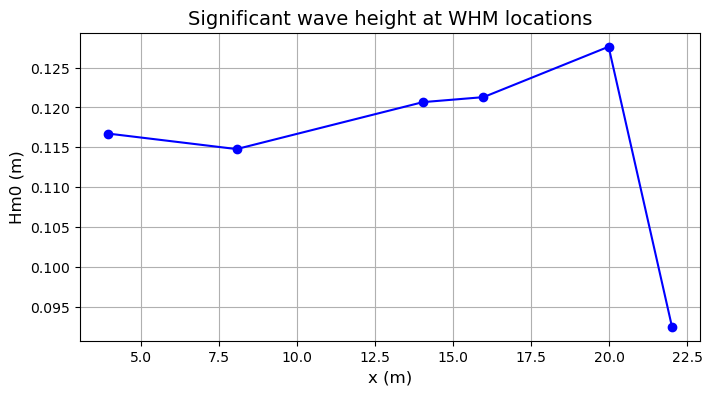

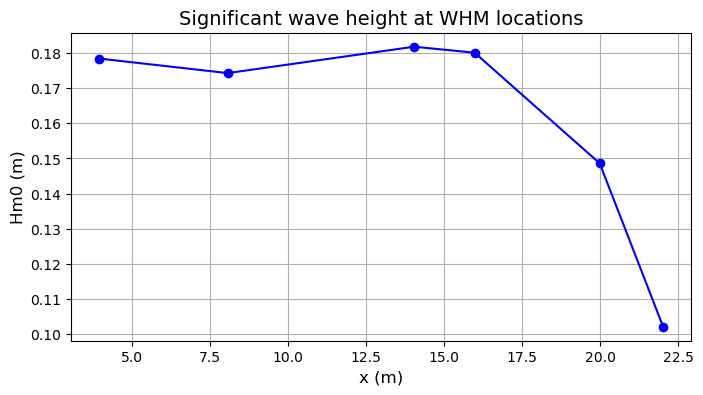

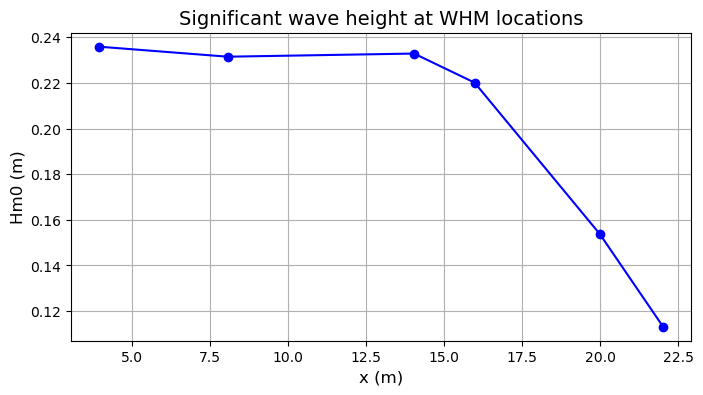

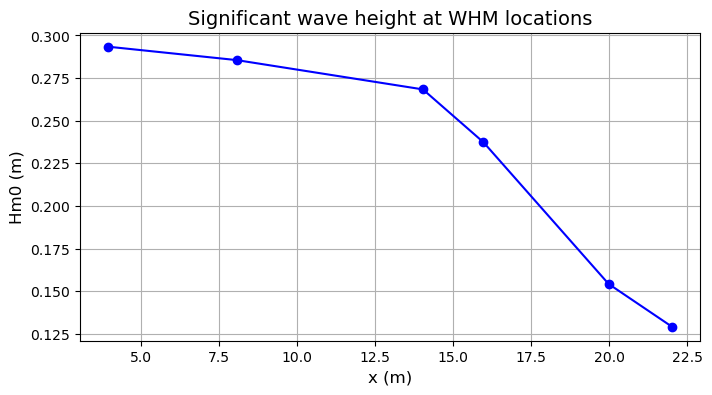

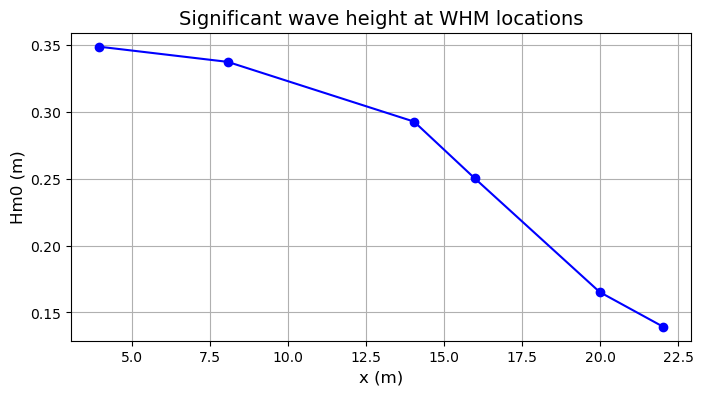

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
from scipy.fftpack import fft
from scipy.stats import chi2
import oceanwaves as ow


def load_whm(filepath):
    # Load all data from the file, skipping the 7-line header
    raw = np.genfromtxt(filepath, delimiter=";", skip_header=7)

    time = raw[:, 0]
    WHM1 = raw[:, 1]
    WHM2 = raw[:, 2]
    WHM3 = raw[:, 3]
    WHM4 = raw[:, 4]
    WHM5 = raw[:, 5]
    WHM6 = raw[:, 6]

    # Remove the mean of the first 60 seconds (still water baseline)
    # This gives us eta = 0 at rest, so any deviation is a wave
    still_water_mask = time < 60
    WHM1 -= np.mean(WHM1[still_water_mask])
    WHM2 -= np.mean(WHM2[still_water_mask])
    WHM3 -= np.mean(WHM3[still_water_mask])
    WHM4 -= np.mean(WHM4[still_water_mask])
    WHM5 -= np.mean(WHM5[still_water_mask])
    WHM6 -= np.mean(WHM6[still_water_mask])

    # Trim the first and last 200 seconds
    mask = (time >= 200) & (time <= time[-1] - 200)
    time = time[mask]
    WHM1, WHM2, WHM3, WHM4, WHM5, WHM6 = WHM1[mask], WHM2[mask], WHM3[mask], WHM4[mask], WHM5[mask], WHM6[mask]

   
    sensitivity = 0.05
    WHM1, WHM2, WHM3, WHM4, WHM5, WHM6 = WHM1*sensitivity, WHM2*sensitivity, WHM3*sensitivity, WHM4*sensitivity, WHM5*sensitivity, WHM6*sensitivity

    return time, WHM1, WHM2, WHM3, WHM4, WHM5, WHM6


def plot_spectra(time, WHM1, WHM2, WHM3, WHM4, WHM5, WHM6, nBlocks=5):
    Fs            = 1 / (time[1] - time[0])
    whm_data      = [WHM1, WHM2, WHM3, WHM4, WHM5, WHM6]
    whm_positions = [3.95, 8.06, 14.03, 15.97, 19.98, 22.01]

    fig, axes = plt.subplots(6, 1, figsize=(10, 18), sharex=True)

    for i, (ax, WHM, pos) in enumerate(zip(axes, whm_data, whm_positions), start=1):

        # Compute spectrum
        nfft      = int(len(WHM)/nBlocks)
        nfft      = nfft - (nfft % 2)
        df        = Fs / nfft
        f         = np.arange(0, Fs/2 + df, df)
        blocks    = np.reshape(WHM[:nBlocks*nfft], (nBlocks, nfft))
        fft_data  = 2 * fft(blocks, n=nfft, axis=1)[:, :len(f)] / nfft
        E         = np.mean(np.abs(fft_data)**2 / 2, axis=0) / df
        edf       = nBlocks * 2
        confLow   = edf / chi2.ppf(0.95, edf)
        confHigh  = edf / chi2.ppf(0.05, edf)

        ax.plot(f, E, color='blue')
        ax.set_xlim(0, 1)
        ax.set_ylabel('E (m²/Hz)')
        ax.set_title(f'WHM{i} at x={pos}m')
        ax.axvline(x=0.5,  linestyle='--', color='red',   alpha=0.5, label='Peak (2s)')
        ax.axvline(x=0.05, linestyle='--', color='green', alpha=0.5, label='IG cutoff')
        ax.grid()

    axes[0].legend()
    axes[-1].set_xlabel('Frequency (Hz)')
    plt.suptitle('Wave energy spectra at WHM locations', fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_hm0(time, WHM1, WHM2, WHM3, WHM4, WHM5, WHM6, nBlocks=5):
    Fs            = 1 / (time[1] - time[0])
    whm_data      = [WHM1, WHM2, WHM3, WHM4, WHM5, WHM6]
    whm_positions = [3.95, 8.06, 14.03, 15.97, 19.98, 22.01]

    hm0 = []
    for WHM in whm_data:
        nfft     = int(len(WHM)/nBlocks)
        nfft     = nfft - (nfft % 2)
        df       = Fs / nfft
        f        = np.arange(0, Fs/2 + df, df)
        blocks   = np.reshape(WHM[:nBlocks*nfft], (nBlocks, nfft))
        fft_data = 2 * fft(blocks, n=nfft, axis=1)[:, :len(f)] / nfft
        E        = np.mean(np.abs(fft_data)**2 / 2, axis=0) / df

        m0 = np.trapz(E, f)           # zeroth spectral moment
        hm0.append(4 * np.sqrt(m0))   # significant wave height

    plt.figure(figsize=(8, 4))
    plt.plot(whm_positions, hm0, color='blue', marker='o', markersize=6)
    plt.xlabel('x (m)', fontsize=12)
    plt.ylabel('Hm0 (m)', fontsize=12)
    plt.title('Significant wave height at WHM locations', fontsize=14)
    plt.grid()
    plt.show()


time1, WHM1_03, WHM2_03, WHM3_03, WHM4_03, WHM5_03, WHM6_03 = load_whm('Set1/WHM_test1.ASC')
time2, WHM1_06, WHM2_06, WHM3_06, WHM4_06, WHM5_06, WHM6_06 = load_whm('Set2/WHM_test2.ASC')
time3, WHM1_09, WHM2_09, WHM3_09, WHM4_09, WHM5_09, WHM6_09 = load_whm('Set3/WHM_test3.ASC')
time4, WHM1_12, WHM2_12, WHM3_12, WHM4_12, WHM5_12, WHM6_12 = load_whm('Set4/WHM_test4.ASC')
time5, WHM1_15, WHM2_15, WHM3_15, WHM4_15, WHM5_15, WHM6_15 = load_whm('Set5/WHM_test5.ASC')
time6, WHM1_18, WHM2_18, WHM3_18, WHM4_18, WHM5_18, WHM6_18 = load_whm('Set6/WHM_test6.ASC')


plot_spectra(time1, WHM1_03, WHM2_03, WHM3_03, WHM4_03, WHM5_03, WHM6_03)
plot_spectra(time2, WHM1_06, WHM2_06, WHM3_06, WHM4_06, WHM5_06, WHM6_06)
plot_spectra(time3, WHM1_09, WHM2_09, WHM3_09, WHM4_09, WHM5_09, WHM6_09)
plot_spectra(time4, WHM1_12, WHM2_12, WHM3_12, WHM4_12, WHM5_12, WHM6_12)
plot_spectra(time5, WHM1_15, WHM2_15, WHM3_15, WHM4_15, WHM5_15, WHM6_15)
plot_spectra(time6, WHM1_18, WHM2_18, WHM3_18, WHM4_18, WHM5_18, WHM6_18)


plot_hm0(time1, WHM1_03, WHM2_03, WHM3_03, WHM4_03, WHM5_03, WHM6_03)
plot_hm0(time2, WHM1_06, WHM2_06, WHM3_06, WHM4_06, WHM5_06, WHM6_06)
plot_hm0(time3, WHM1_09, WHM2_09, WHM3_09, WHM4_09, WHM5_09, WHM6_09)
plot_hm0(time4, WHM1_12, WHM2_12, WHM3_12, WHM4_12, WHM5_12, WHM6_12)
plot_hm0(time5, WHM1_15, WHM2_15, WHM3_15, WHM4_15, WHM5_15, WHM6_15)
plot_hm0(time6, WHM1_18, WHM2_18, WHM3_18, WHM4_18, WHM5_18, WHM6_18)
